In [9]:
# import mesa_reader to make its classes accessible
import mesa_reader as mr
import matplotlib.pyplot as plt
import os
import numpy as np

In [10]:
# Source - https://stackoverflow.com/a/2566508
# Posted by unutbu, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-06, License - CC BY-SA 4.0

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]


## Plot isochrones on HR diagram

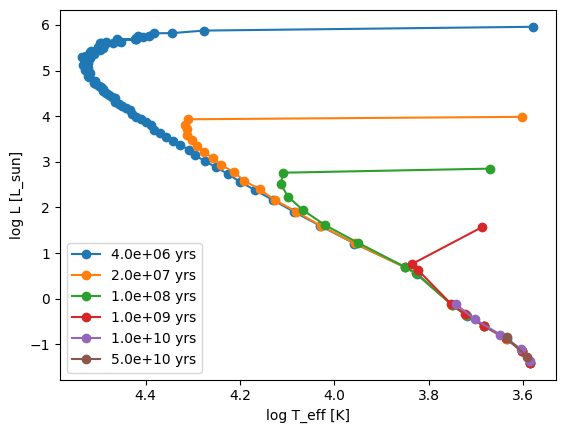

In [206]:
ages = np.array([4e6, 2e7, 1e8, 1e9, 1e10, 5e10])
# ages = np.logspace(6.6, 11, 50)
# ages = np.linspace(1e6, 1e7, 10)
turnoff_masses = []
plt.figure()
for i, age in enumerate(ages):
    turnoff_mass = 0

    log_Teffs = []
    log_Ls = []

    for star in np.sort(os.listdir('../isochrones/')):
        if star.startswith('iso_') and os.path.isfile(f'../isochrones/{star}/LOGS/history.data') and not star.startswith('iso_2.0M'):
            h = mr.MesaData(f'../isochrones/{star}/LOGS/history.data')
            max_age = h.star_age[-1]
            if max_age >= age:
                if h.star_mass[0] > turnoff_mass:
                    # this section of the code was run with just TAMS stellar models, not full isochrones
                    turnoff_mass = h.star_mass[0]
                idx, _ = find_nearest(h.star_age, age) # set last age of model to be age of cluster; round up even if star is younger than cluster since assuming slow evolution post stopping condition of sim.
                log_Teffs.append(h.log_Teff[idx])
                log_Ls.append(h.log_L[idx])
            # if star.startswith('iso_50'):
            #     plt.scatter(h.log_Teff[idx], h.log_L[idx], marker='x', s=50, label=f"{age:.1e} yrs")
    # if i % 7 == 0:
    plt.plot((log_Teffs), (log_Ls), marker='o', label=f"{age:.1e} yrs")
    # plt.scatter((log_Teffs), (log_Ls), marker='o', s=3, label=f"{age:.1e} yrs")
        # print(f"Turnoff mass for age {age:.1e} is {turnoff_mass:.1f} Msun")

    turnoff_masses.append(turnoff_mass)

plt.gca().invert_xaxis()
plt.xlabel('log T_eff [K]')
plt.ylabel('log L [L_sun]')
plt.legend()
plt.savefig("../plots/isochrones.png", dpi=300, bbox_inches='tight')
plt.show()

## Convert HR to colour-magnitude diagram

In [190]:
# convert T to B-V colour using Torres (2010) polynomial fit: https://iopscience.iop.org/article/10.1088/0004-6256/140/5/1158/pdf
def T_to_BV(logT):
    coeff = [3.979145106714099 - logT, -0.654992268598245, 1.740690042385095, -4.608815154057166, 6.792599779944473, -5.396909891322525, 2.192970376522490, -0.359495739295671]
    roots = np.roots(coeff[::-1])
    BV = roots[np.where(roots == roots.real)][0].real
    return BV

def L_to_V(logL, logT):
    M_bol_sun = 4.73
    M_bol = M_bol_sun - 2.5 * logL
    if logT < 3.70:
        coeff = [-0.190537291496456E+05, 0.155144866764412E+05, -0.421278819301717E+04, 0.381476328422343E+03]
    elif logT < 3.90:
        coeff = [-0.370510203809015E+05, 0.385672629965804E+05, -0.150651486316025E+05, 0.261724637119416E+04, -0.170623810323864E+03]
    else:
        coeff = [-0.118115450538963E+06, 0.137145973583929E+06, -0.636233812100225E+05, 0.147412923562646E+05, -0.170587278406872E+04, 0.788731721804990E+02]

    BC = np.polyval(coeff[::-1], logT)
    M_V = M_bol - BC
    return M_V

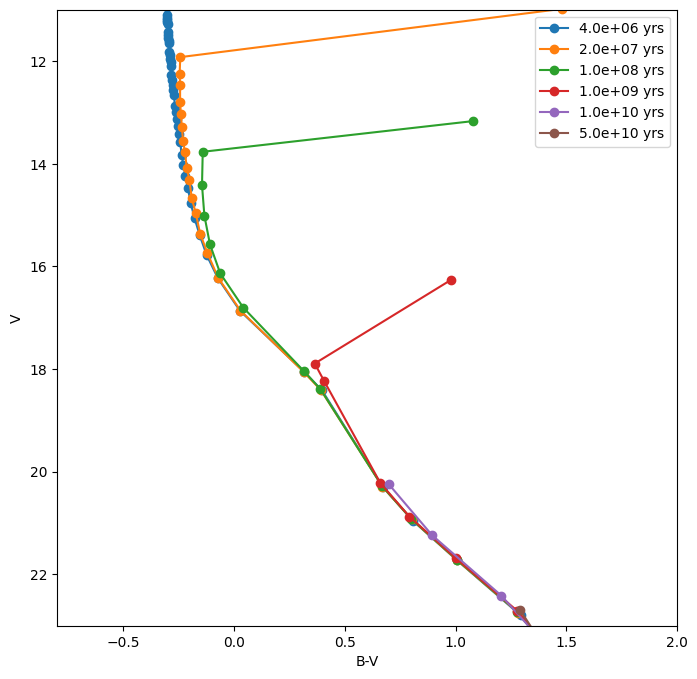

In [209]:
plt.figure(figsize=(8, 8))
E = -0.01 # extinction for M3
d = 10.4*10**3 # pc, distance modulus for M3
ages_M3 = np.linspace(1e9, 1e11, 10)
ages_M3 = np.array([4e6, 2e7, 1e8, 1e9, 1e10, 5e10])
for i, age in enumerate(ages_M3):
    BVs = []
    Vmags = []
    for star in np.sort(os.listdir('../isochrones/')):
        if star.startswith('iso_') and os.path.isfile(f'../isochrones/{star}/LOGS/history.data') and not star.startswith('iso_2.0M'):
            h = mr.MesaData(f'../isochrones/{star}/LOGS/history.data')
            max_age = h.star_age[-1]
            if max_age >= age:
                idx, _ = find_nearest(h.star_age, age)
                Vmags.append(L_to_V(h.log_L[idx], h.log_Teff[idx]))
                BVs.append(T_to_BV(h.log_Teff[idx]))
    # if i % 7 == 0:
    BVs = np.array(BVs)
    Vmags = np.array(Vmags)
    # plt.scatter(BVs + E, Vmags + 5*(np.log10(d)-1), marker='o', s=3, label=f"{age:.1e} yrs")
    plt.plot(BVs + E, Vmags + 5*(np.log10(d)-1), marker='o', label=f"{age:.1e} yrs")

plt.gca().invert_yaxis()
plt.ylim(23, 11)
plt.xlim(-0.8, 2)
plt.xlabel('B-V')
plt.ylabel('V')
plt.legend()
plt.savefig("../plots/cmd.png", dpi=300, bbox_inches='tight')
plt.show()

## Plot turnoff mass vs. age

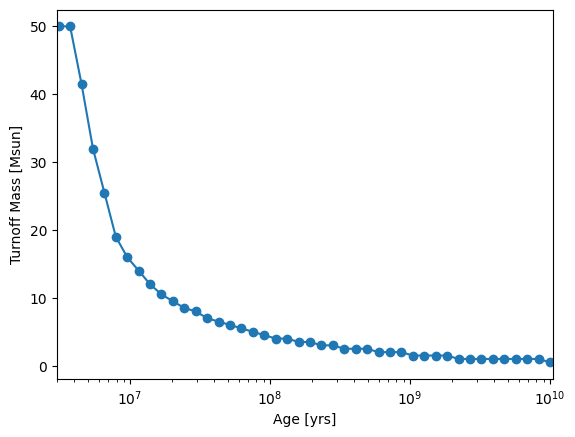

In [25]:
plt.figure()
plt.plot(ages, turnoff_masses, marker='o')
plt.xlim(3e6)
plt.xscale('log')
plt.xlabel('Age [yrs]')
plt.ylabel('Turnoff Mass [Msun]')
plt.savefig("../plots/turnoff_mass.png", bbox_inches='tight')
# plt.show()